# Stock Price Prediction — GRU vs LSTM vs Transformer (Benchmark)

Single-notebook version: everything (data, features, models, training, evaluation,
plots) lives in the cells below, in order. Run all cells top to bottom.

**Extends the original GRU-only project** with:
- **LSTM** and an **encoder-only Transformer**, benchmarked against the GRU
- **Baselines**: naive persistence + linear regression, so the deep models are
  compared against something meaningful
- **Richer features**: Close, Volume, Returns, SMA(10/20), EMA(12/26), MACD, RSI(14),
  Bollinger Band width — instead of Close price alone
- **Leakage-free evaluation**: chronological train/val/test split, scaler fit on
  train only, early stopping on validation loss
- **Metrics**: RMSE, MAE, MAPE, and directional accuracy (up/down correctness) for
  every model, in one comparison table

> **Requires internet access** (to download prices from Yahoo Finance via `yfinance`).
> Run this in Google Colab or locally — it will not run in a network-restricted
> sandbox.

In [1]:
# If running in Google Colab, uncomment the line below.
# !pip install -q yfinance torch scikit-learn pandas numpy matplotlib tabulate

import math
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import yfinance as yf

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Configuration

Change the ticker, date range, or hyperparameters here and re-run everything below.

In [2]:
TICKER      = "AAPL"
START       = "2015-01-01"
END         = "2025-01-01"

SEQ_LEN     = 30       # days of history per training window
TRAIN_FRAC  = 0.70
VAL_FRAC    = 0.15     # remainder (0.15) is the test set

HIDDEN_SIZE = 64
NUM_LAYERS  = 2
EPOCHS      = 150
BATCH_SIZE  = 32
LR          = 1e-3
PATIENCE    = 15       # early stopping

## 2. Download data & engineer features

Downloads OHLCV data, then adds common technical indicators. This is the "beyond a
single Close-price feature" extension.

In [3]:
def download_prices(ticker, start, end):
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna()
    if df.empty:
        raise ValueError(f"No data returned for {ticker} between {start} and {end}.")
    return df


def add_technical_indicators(df):
    out = df.copy()
    out["Return"] = out["Close"].pct_change()

    out["SMA_10"] = out["Close"].rolling(10).mean()
    out["SMA_20"] = out["Close"].rolling(20).mean()

    out["EMA_12"] = out["Close"].ewm(span=12, adjust=False).mean()
    out["EMA_26"] = out["Close"].ewm(span=26, adjust=False).mean()
    out["MACD"] = out["EMA_12"] - out["EMA_26"]

    delta = out["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / avg_loss.replace(0, 1e-9)
    out["RSI_14"] = 100 - (100 / (1 + rs))

    sma20 = out["Close"].rolling(20).mean()
    std20 = out["Close"].rolling(20).std()
    out["BB_upper"] = sma20 + 2 * std20
    out["BB_lower"] = sma20 - 2 * std20
    out["BB_width"] = (out["BB_upper"] - out["BB_lower"]) / sma20

    return out


raw = download_prices(TICKER, START, END)
feat_df = add_technical_indicators(raw)

FEATURE_COLS = [
    "Close", "Volume", "Return", "SMA_10", "SMA_20",
    "EMA_12", "EMA_26", "MACD", "RSI_14", "BB_width",
]
TARGET_COL = "Close"

feat_df = feat_df[FEATURE_COLS].dropna()
print(f"{len(feat_df)} rows after indicator warm-up, {len(FEATURE_COLS)} features")
feat_df.tail()

2497 rows after indicator warm-up, 10 features


Price,Close,Volume,Return,SMA_10,SMA_20,EMA_12,EMA_26,MACD,RSI_14,BB_width
Date,,,,,,,,,,
2024-12-24,256.560883,23234700,0.011478,249.694693,244.729908,248.869633,242.834192,6.035441,76.180618,0.106352
2024-12-26,257.375610,27237100,0.003176,250.939738,245.920303,250.178245,243.911334,6.266911,76.812024,0.106295
2024-12-27,253.967392,42355300,-0.013242,251.697896,246.946745,250.761191,244.656228,6.104963,69.300646,0.098269
2024-12-30,250.598907,35557500,-0.013263,252.102312,247.685525,250.736224,245.096426,5.639798,58.382013,0.089074
2024-12-31,248.830215,39480700,-0.007058,252.040706,248.223589,250.442992,245.373003,5.069989,53.982546,0.081084


## 3. Leakage-free train/val/test split

The original notebook trained on 100% of the data with no validation set at all. Here
the split is strictly chronological, and the scaler is fit on the **training data
only** (val/test are transformed with that same scaler, never re-fit) to avoid
look-ahead bias.

In [4]:
target_idx = FEATURE_COLS.index(TARGET_COL)

n = len(feat_df)
n_train = int(n * TRAIN_FRAC)
n_val = int(n * VAL_FRAC)

train_df = feat_df.iloc[:n_train]
val_df   = feat_df.iloc[n_train:n_train + n_val]
test_df  = feat_df.iloc[n_train + n_val:]

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_df.values)

train_scaled = scaler.transform(train_df.values)
val_scaled   = scaler.transform(val_df.values)
test_scaled  = scaler.transform(test_df.values)

target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.min_          = np.array([scaler.min_[target_idx]])
target_scaler.scale_        = np.array([scaler.scale_[target_idx]])
target_scaler.data_min_     = np.array([scaler.data_min_[target_idx]])
target_scaler.data_max_     = np.array([scaler.data_max_[target_idx]])
target_scaler.data_range_   = np.array([scaler.data_range_[target_idx]])
target_scaler.n_features_in_ = 1


def make_windows(arr, seq_len, target_idx):
    x, y = [], []
    for i in range(len(arr) - seq_len):
        x.append(arr[i:i + seq_len])
        y.append(arr[i + seq_len, target_idx])
    return np.array(x, dtype=np.float32), np.array(y, dtype=np.float32).reshape(-1, 1)


# Prepend the tail of the previous split so val/test windows aren't truncated at
# the boundary (chronological — no label leakage, only already-observed history).
val_input  = np.concatenate([train_scaled[-SEQ_LEN:], val_scaled], axis=0)
test_input = np.concatenate([val_scaled[-SEQ_LEN:], test_scaled], axis=0)

x_train, y_train = make_windows(train_scaled, SEQ_LEN, target_idx)
x_val,   y_val   = make_windows(val_input,   SEQ_LEN, target_idx)
x_test,  y_test  = make_windows(test_input,  SEQ_LEN, target_idx)

print(f"train windows: {len(x_train)} | val windows: {len(x_val)} | test windows: {len(x_test)}")

train windows: 1717 | val windows: 374 | test windows: 376


## 4. Models: GRU, LSTM, Transformer

Same input/output shape for all three, so they're directly comparable. The GRU is the
original architecture (device bug fixed, dropout + multivariate input added). The
Transformer is encoder-only with a learned/sinusoidal positional encoding — the
architecture family that has largely superseded RNNs for sequence modeling, and a
natural "what's next" after a GRU project.

In [5]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.gru(x, h0)
        return self.fc(out[:, -1, :])


class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                             dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_size=1, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, output_size=1, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, output_size)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        out = self.encoder(x)
        return self.fc(out[:, -1, :])


n_features = len(FEATURE_COLS)
print(f"Models will take {n_features} input features per timestep.")

Models will take 10 input features per timestep.


## 5. Baselines: naive persistence & linear regression

A benchmark table means little without something non-deep-learning to compare against.

In [6]:
def naive_persistence(x, target_idx):
    return x[:, -1, target_idx].reshape(-1, 1)


def linear_regression_baseline(x_train, y_train, x_test):
    n_train, n_test = x_train.shape[0], x_test.shape[0]
    x_train_flat = x_train.reshape(n_train, -1)
    x_test_flat = x_test.reshape(n_test, -1)
    model = LinearRegression().fit(x_train_flat, y_train.ravel())
    return model.predict(x_test_flat).reshape(-1, 1)

## 6. Training loop (with validation + early stopping)

The original notebook trained for a fixed 100 epochs on the full dataset with no
validation signal. This version tracks validation loss each epoch, keeps the
best-performing weights, and stops early if validation stops improving.

In [7]:
def train_model(model, x_train, y_train, x_val, y_val, device,
                 epochs=150, batch_size=32, lr=1e-3, patience=15, verbose=True):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_ds = TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    x_val_t = torch.from_numpy(x_val).to(device)
    y_val_t = torch.from_numpy(y_val).to(device)

    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(train_ds)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(x_val_t), y_val_t).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and epoch % 10 == 0:
            print(f"  epoch {epoch:3d}/{epochs} | train_loss {train_loss:.6f} | val_loss {val_loss:.6f}")

        if epochs_no_improve >= patience:
            if verbose:
                print(f"  early stopping at epoch {epoch} (best val_loss {best_val_loss:.6f})")
            break

    model.load_state_dict(best_state)
    return model, history

## 7. Train all three models

In [8]:
predictions = {}
histories = {}

print("Naive persistence baseline...")
predictions["Naive"] = naive_persistence(x_test, target_idx)

print("Linear regression baseline...")
predictions["LinearRegression"] = linear_regression_baseline(x_train, y_train, x_test)

model_configs = {
    "GRU": GRUModel(input_size=n_features, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS),
    "LSTM": LSTMModel(input_size=n_features, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS),
    "Transformer": TimeSeriesTransformer(input_size=n_features, d_model=HIDDEN_SIZE, nhead=4, num_layers=NUM_LAYERS),
}

for name, model in model_configs.items():
    print(f"\nTraining {name} ...")
    trained, history = train_model(model, x_train, y_train, x_val, y_val, device,
                                    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE)
    trained.eval()
    with torch.no_grad():
        preds = trained(torch.from_numpy(x_test).to(device)).cpu().numpy()
    predictions[name] = preds
    histories[name] = history

print("\nAll models trained.")

Naive persistence baseline...
Linear regression baseline...

Training GRU ...
  epoch  10/150 | train_loss 0.000441 | val_loss 0.001169
  epoch  20/150 | train_loss 0.000226 | val_loss 0.000744
  epoch  30/150 | train_loss 0.000213 | val_loss 0.000593
  epoch  40/150 | train_loss 0.000208 | val_loss 0.000534
  epoch  50/150 | train_loss 0.000213 | val_loss 0.000462
  epoch  60/150 | train_loss 0.000162 | val_loss 0.000492
  epoch  70/150 | train_loss 0.000139 | val_loss 0.000413
  epoch  80/150 | train_loss 0.000124 | val_loss 0.000609
  early stopping at epoch 84 (best val_loss 0.000409)

Training LSTM ...
  epoch  10/150 | train_loss 0.000432 | val_loss 0.001178
  epoch  20/150 | train_loss 0.000343 | val_loss 0.000870
  epoch  30/150 | train_loss 0.000220 | val_loss 0.000714
  epoch  40/150 | train_loss 0.000196 | val_loss 0.000552
  epoch  50/150 | train_loss 0.000208 | val_loss 0.000506
  epoch  60/150 | train_loss 0.000205 | val_loss 0.000922
  early stopping at epoch 65 (best va

## 8. Evaluate every model on the same test set

RMSE, MAE, MAPE, and directional accuracy (did the model call the up/down move
right?). Naive persistence scores 0% directional accuracy by construction — it never
predicts a change — which is exactly why it's included: it's a useful floor, not a
model to beat on every metric.

In [10]:
def inverse_target(arr):
    return target_scaler.inverse_transform(arr.reshape(-1, 1)).ravel()


def regression_metrics(y_true, y_pred):
    y_true, y_pred = y_true.ravel(), y_pred.ravel()
    mse = float(np.mean((y_true - y_pred) ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    nonzero = y_true != 0
    mape = float(np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100)
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "MAPE (%)": mape}


def directional_accuracy(y_true_prices, y_pred_prices, prev_prices):
    true_dir = np.sign(y_true_prices.ravel() - prev_prices.ravel())
    pred_dir = np.sign(y_pred_prices.ravel() - prev_prices.ravel())
    return float(np.mean(true_dir == pred_dir) * 100)


y_test_prices = inverse_target(y_test)
raw_close_test = test_df[TARGET_COL].values
prev_prices = np.concatenate([[raw_close_test[0]], y_test_prices[:-1]])

price_predictions = {name: inverse_target(p) for name, p in predictions.items()}

rows = []
for name, pred_prices in price_predictions.items():
    pred_prices = pred_prices[:len(y_test_prices)]
    m = regression_metrics(y_test_prices, pred_prices)
    m["Directional Accuracy (%)"] = directional_accuracy(y_test_prices, pred_prices, prev_prices)
    m["Model"] = name
    rows.append(m)

results_df = pd.DataFrame(rows).set_index("Model")
results_df = results_df[["RMSE", "MAE", "MAPE (%)", "MSE", "Directional Accuracy (%)"]]
results_df = results_df.sort_values("RMSE").round(4)

results_df.to_csv("benchmark_results.csv")
with open("benchmark_results.md", "w") as f:
    f.write(f"# Benchmark results — {TICKER} ({START} to {END})\n\n")
    f.write(results_df.to_markdown())

results_df

,RMSE,MAE,MAPE (%),MSE,Directional Accuracy (%)
Model,,,,,
Naive,2.6656,1.9642,0.9985,7.1056,0.2660
LinearRegression,2.8394,2.1225,1.0792,8.0621,52.6596
GRU,6.6952,5.0614,2.4042,44.8257,45.7447
Transformer,7.9666,6.0696,2.8665,63.4662,43.6170
LSTM,14.8590,10.6536,4.9098,220.7902,44.1489


## 9. Plots

Also saved to `predictions_vs_actual.png` and `training_curves.png`.

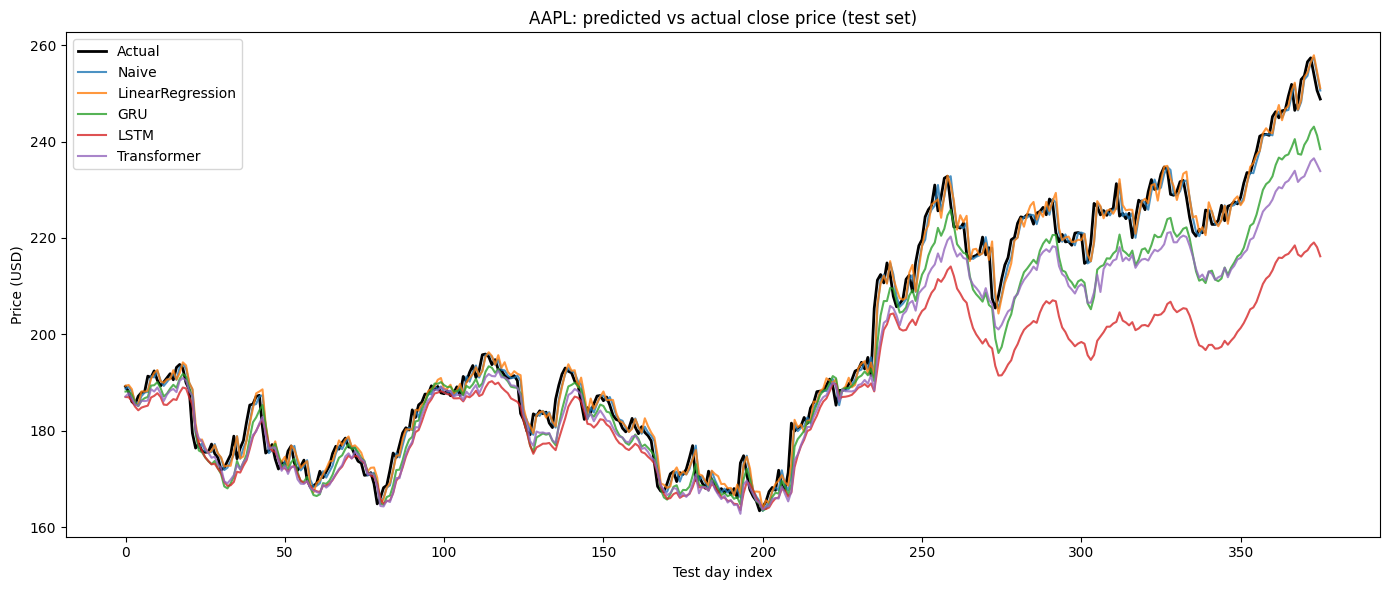

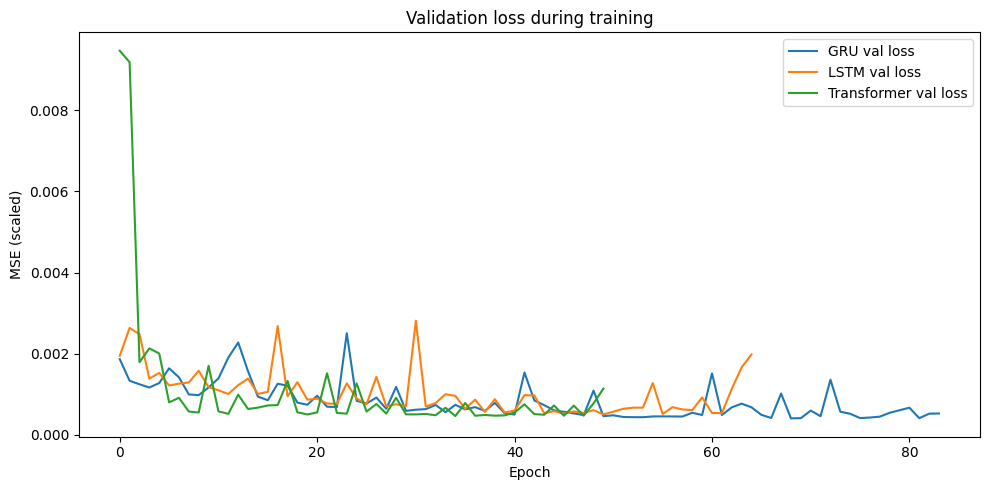

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(y_test_prices, label="Actual", color="black", linewidth=2)
for name, pred_prices in price_predictions.items():
    plt.plot(pred_prices[:len(y_test_prices)], label=name, alpha=0.8)
plt.title(f"{TICKER}: predicted vs actual close price (test set)")
plt.xlabel("Test day index")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig("predictions_vs_actual.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
for name, h in histories.items():
    plt.plot(h["val_loss"], label=f"{name} val loss")
plt.title("Validation loss during training")
plt.xlabel("Epoch")
plt.ylabel("MSE (scaled)")
plt.legend()
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()